# Assignment 2: Market Participation (Stakeholder Perspective)

In [135]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import glob
import os


### Preliminary: preparing the wind, prices and imbalance data

In [136]:
def load_and_scale_data(gen_folder, price_folder, target_capacity=500, p_deficit=0.5):
    # --- Wind loading (unchanged) ---
    wind_files = sorted(glob.glob(os.path.join(gen_folder, "*.csv")))
    wind_scenarios = []
    for f in wind_files:
        df = pd.read_csv(f, sep=None, engine='python').ffill().fillna(0)
        raw_values = pd.to_numeric(df.iloc[:, 7], errors='coerce').fillna(0).values
        clean_values = np.zeros(24)
        n_available = min(len(raw_values), 24)
        clean_values[:n_available] = raw_values[:n_available]
        unit_max = clean_values.max()
        wind_scenarios.append((clean_values / unit_max) * target_capacity if unit_max > 0 else clean_values)

    # --- Price loading (unchanged) ---
    price_files = sorted(glob.glob(os.path.join(price_folder, "*.csv")))
    price_scenarios = []
    for f in price_files:
        p_df = pd.read_csv(f, sep=None, engine='python').ffill().fillna(0)
        price_values = pd.to_numeric(p_df.iloc[:, 3], errors='coerce').fillna(0).values
        clean_prices = np.zeros(24)
        n_available = min(len(price_values), 24)
        clean_prices[:n_available] = price_values[:n_available]
        price_scenarios.append(clean_prices)

    # --- NEW: Generate 2 deterministic SI scenarios (Bernoulli, p=0.5) ---
    # SI scenario 0: all-surplus  (SI=0 for all hours) — P=0.5^24 combined
    # SI scenario 1: all-deficit  (SI=1 for all hours) — P=0.5^24 combined
    # Better: use 2 representative draws from Bernoulli for each hour
    rng = np.random.default_rng(42)  # fixed seed for reproducibility
    si_scenarios = [
        rng.binomial(1, p_deficit, size=24).astype(float),  # SI draw 1
        rng.binomial(1, p_deficit, size=24).astype(float),  # SI draw 2
    ]

    # --- Cartesian Product: wind × price × SI ---
    final_wind, final_prices, final_si = [], [], []
    for w in wind_scenarios:
        for p in price_scenarios:
            for si in si_scenarios:
                final_wind.append(w)
                final_prices.append(p)
                final_si.append(si)

    return (
        np.array(final_wind).T,    # shape (24, n_scenarios)
        np.array(final_prices).T,  # shape (24, n_scenarios)
        np.array(final_si).T,      # shape (24, n_scenarios)  ← NEW
        len(final_wind)
    )

# Execute Loading
wind_realized, lambda_da, SI_scenarios, n_scenarios = load_and_scale_data(
    'data/Generation', 'data/Prices', 500
)

print(f"Total Scenarios: {n_scenarios}")  # Should be 1922
print(f"Wind shape: {wind_realized.shape}")
print(f"SI shape:   {SI_scenarios.shape}")

Total Scenarios: 1922
Wind shape: (24, 1922)
SI shape:   (24, 1922)


In [137]:
# To ensure we have the expected dimensions
print(f"Max wind value in all scenarios: {wind_realized.max()} MW")
print(f"Min wind value in all scenarios: {wind_realized.min()} MW")

Max wind value in all scenarios: 500.0 MW
Min wind value in all scenarios: 0.0 MW


### Task 1.1


In [138]:
# --- Step 2: Gurobi Model Setup ---
# Basic Parameters
n_scenarios = wind_realized.shape[1] # Should be 1922
hours = 24
P_nom = 500  # Target capacity used in scaling
prob = 1.0 / n_scenarios

# Create the Model
m = gp.Model("Wind_Farm_Offering_Task_1_1")

# Force Gurobi to ignore dual reductions so it says if it is Unbounded or Infeasible
m.setParam('DualReductions', 0)

# 1. Decision Variables
# First-stage: One offer per hour, shared across all scenarios (First Stage)
p_da = m.addVars(hours, lb=0, ub=P_nom, name="p_da")

# Second-stage: Imbalances (Scenario dependent)
# We add an upper bound (ub) equal to P_nom. 
# This prevents "Infinite Profit" loops during periods of negative prices.
delta_plus = m.addVars(hours, n_scenarios, lb=0, ub=P_nom, name="delta_plus")
delta_minus = m.addVars(hours, n_scenarios, lb=0, ub=P_nom, name="delta_minus")

# Balancing prices derived from SI and DA price
# BP = 1.25 * DA if deficit (SI=1), BP = 0.85 * DA if surplus (SI=0)
lambda_bp = SI_scenarios * (1.25 * lambda_da) + (1 - SI_scenarios) * (0.85 * lambda_da)

# Objective (one-price scheme: always settle at BP)
obj = gp.quicksum(
    prob * (
        lambda_da[t, s] * p_da[t]
        + lambda_bp[t, s] * delta_plus[t, s]   # excess settled at BP
        - lambda_bp[t, s] * delta_minus[t, s]  # deficit settled at BP
    )
    for t in range(hours) for s in range(n_scenarios)
)
m.setObjective(obj, GRB.MAXIMIZE)

# 3. Constraints
# Realized Wind - DA Offer = Excess - Deficit
for t in range(hours):
    for s in range(n_scenarios):
        m.addConstr(
            wind_realized[t, s] - p_da[t] == delta_plus[t, s] - delta_minus[t, s],
            name=f"imbalance_{t}_{s}"
        )

# 4. Solve
m.optimize()

# 5. Get and Display Results
if m.status == GRB.OPTIMAL:
    print(f"\nOptimization Successful!")
    print(f"Expected Daily Profit: {m.ObjVal:.2f} EUR")
    
    # Store the 24-hour optimal offer profile
    optimal_offers = [p_da[t].X for t in range(hours)]
    
    print("\nOptimal Day-Ahead Offers (MW):")
    for h, val in enumerate(optimal_offers):
        print(f"Hour {h:02d}: {val:6.2f} MW")
        

Set parameter DualReductions to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
DualReductions  0

Optimize a model with 46128 rows, 92280 columns and 138384 nonzeros (Max)
Model fingerprint: 0x28f34257
Model has 92032 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [4e-06, 1e+02]
  Bounds range     [5e+02, 5e+02]
  RHS range        [7e-02, 5e+02]

Presolve time: 0.10s
Presolved: 46128 rows, 92280 columns, 138384 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.02s

Barrier statistics:
 Dense cols : 24
 AA' NZ     : 3.358e+04
 Factor NZ  : 6.718e+04 (roughly 40 MB of memory)
 Factor Ops : 1.343e+05 (less than 1 second per iteration)
 Threads    :

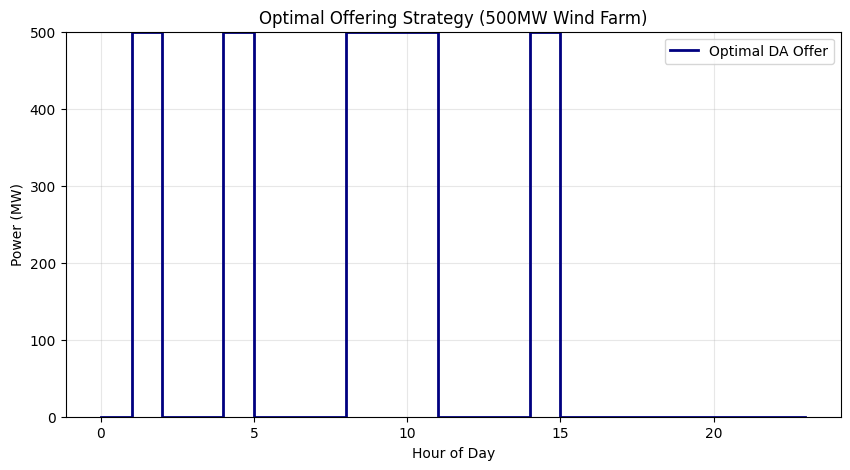

In [139]:
plt.figure(figsize=(10, 5))
plt.step(range(24), optimal_offers, where='post', label='Optimal DA Offer', color='navy', lw=2)
plt.xlabel('Hour of Day')
plt.ylabel('Power (MW)')
plt.title('Optimal Offering Strategy (500MW Wind Farm)')
plt.ylim(0, 500)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

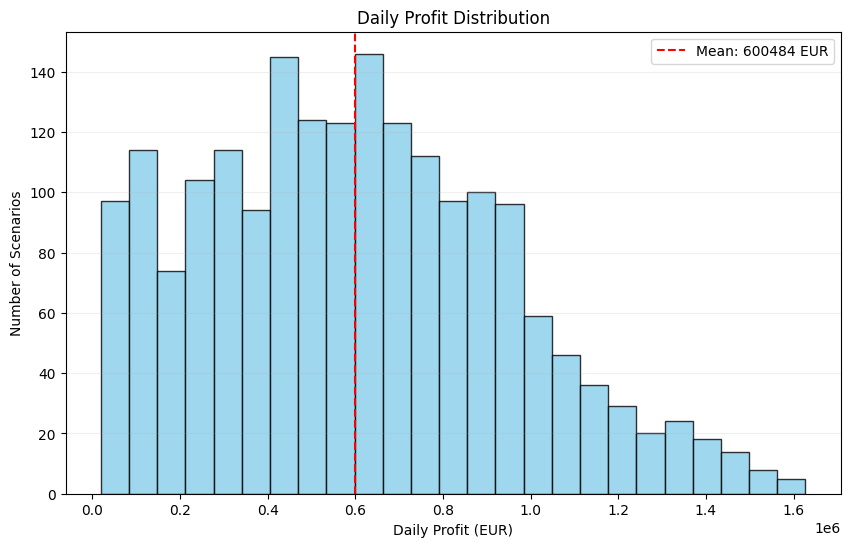

In [140]:
scenario_profits = []
for s in range(n_scenarios):
    profit_s = 0
    for t in range(hours):
        offer = optimal_offers[t]
        wind = wind_realized[t, s]
        d_pos = max(0, wind - offer)
        d_neg = max(0, offer - wind)
        # One-price: all imbalances settle at BP
        profit_s += lambda_da[t, s] * offer + lambda_bp[t, s] * d_pos - lambda_bp[t, s] * d_neg
    scenario_profits.append(profit_s)

# 1. Plot with fewer bins (bars) to group data better
plt.figure(figsize=(10, 6))

plt.hist(scenario_profits, bins=25, color='skyblue', edgecolor='black', alpha=0.8)

# 2. Add the mean line
mean_val = np.mean(scenario_profits)
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.0f} EUR')

# 3. Force Y-axis to show only Integers (no decimals)
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# 4. Final Formatting
plt.title('Daily Profit Distribution')
plt.xlabel('Daily Profit (EUR)')
plt.ylabel('Number of Scenarios')
plt.grid(axis='y', alpha=0.2)
plt.legend()

plt.show()

### Task 1.2 

In [141]:
# --- Task 1.2: Stochastic Offering with Balancing Market Logic ---

# Basic Parameters (derive everything from data)
hours = int(wind_realized.shape[0])        # 24
n_scenarios = wind_realized.shape[1]
P_nom = 500  
prob = 1.0 / n_scenarios

# Create the Model
m = gp.Model("Wind_Farm_Offering_Task_1_2")
m.setParam('DualReductions', 0)

# 1. Decision Variables
# First-stage: Day-ahead offer (MW)
p_da = m.addVars(hours, lb=0, ub=P_nom, name="p_da")

# Second-stage: Imbalances per scenario
delta_plus = m.addVars(hours, n_scenarios, lb=0, ub=P_nom, name="delta_plus")
delta_minus = m.addVars(hours, n_scenarios, lb=0, ub=P_nom, name="delta_minus")

wind_realized[t, s] - p_da[t] == delta_plus[t, s] - delta_minus[t, s]

obj = gp.quicksum(
    prob * (
        lambda_da[t, s] * p_da[t]
        + SI_scenarios[t, s] * (
            1.25 * lambda_da[t, s] * delta_plus[t, s]    # deficit, helpful: rewarded at BP
            - 1.25 * lambda_da[t, s] * delta_minus[t, s] # deficit, harmful: penalised at BP
        )
        + (1 - SI_scenarios[t, s]) * (
            - 0.85 * lambda_da[t, s] * delta_plus[t, s]  # surplus, harmful: penalised at BP
            + 0.85 * lambda_da[t, s] * delta_minus[t, s] # surplus, helpful: rewarded at BP
        )
    )
    for t in range(hours) for s in range(n_scenarios)
)

m.setObjective(obj, GRB.MAXIMIZE)

# 3. Constraints
# Realized Wind - DA Offer = Excess - Deficit
for t in range(hours):
    for s in range(n_scenarios):
        m.addConstr(
            wind_realized[t, s] - p_da[t] == delta_plus[t, s] - delta_minus[t, s],
            name=f"imbalance_{t}_{s}"
        )

# 4. Solve
m.optimize()

# 5. Display Results
if m.status == GRB.OPTIMAL:
    print(f"\nOptimization Successful (Task 1.2)!")
    print(f"Expected Daily Profit: {m.ObjVal:.2f} EUR")
    
    optimal_offers_1_2 = [p_da[t].X for t in range(hours)]
    
    print("\nOptimal Day-Ahead Offers (MW):")
    for h, val in enumerate(optimal_offers_1_2):
        print(f"Hour {h:02d}: {val:6.2f} MW")

Set parameter DualReductions to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
DualReductions  0

Optimize a model with 46128 rows, 92280 columns and 138384 nonzeros (Max)
Model fingerprint: 0x8ac23ccc
Model has 92032 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [4e-06, 1e+02]
  Bounds range     [5e+02, 5e+02]
  RHS range        [7e-02, 5e+02]

Presolve time: 0.07s
Presolved: 46128 rows, 92280 columns, 138384 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.02s

Barrier statistics:
 Dense cols : 24
 AA' NZ     : 3.364e+04
 Factor NZ  : 6.730e+04 (roughly 40 MB of memory)
 Factor Ops : 1.346e+05 (less than 1 second per iteration)
 Threads    :

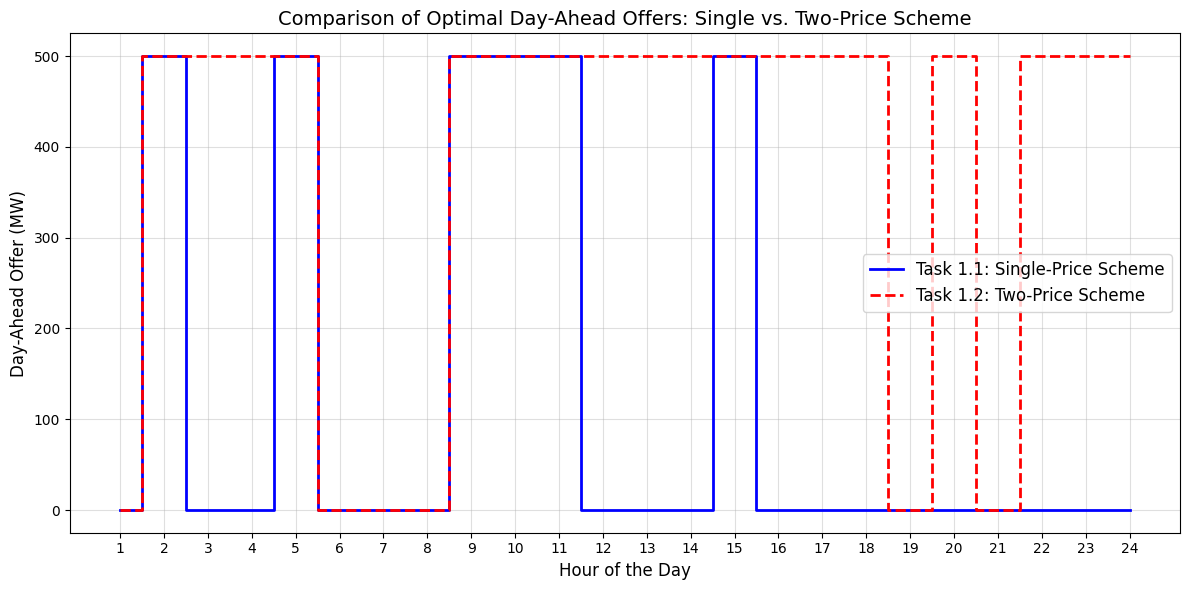

In [142]:
# Histogram of profits for Task 1.2
hours_arr = np.arange(1, 25)

plt.figure(figsize=(12, 6))

# Plot Task 1.1 (Single-Price)
plt.step(hours_arr, optimal_offers, label='Task 1.1: Single-Price Scheme', 
         where='mid', linewidth=2, color='blue')

# Plot Task 1.2 (Two-Price)
plt.step(hours_arr, optimal_offers_1_2, label='Task 1.2: Two-Price Scheme', 
         where='mid', linewidth=2, linestyle='--', color='red')

plt.title('Comparison of Optimal Day-Ahead Offers: Single vs. Two-Price Scheme', fontsize=14)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Day-Ahead Offer (MW)', fontsize=12)
plt.xticks(hours_arr)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [143]:
scenario_profits_2 = []
for s in range(n_scenarios):
    profit_s = 0
    for t in range(hours):
        price = lambda_da[t, s]
        offer = optimal_offers_1_2[t]
        wind = wind_realized[t, s]
        si = SI_scenarios[t, s]   # ← was SI[t, s]

        d_pos = max(0, wind - offer)
        d_neg = max(0, offer - wind)

        if si == 1:  # deficit
            profit_s += price * offer + 1.25 * price * d_pos - 1.25 * price * d_neg
        else:        # surplus
            profit_s += price * offer - 0.85 * price * d_pos + 0.85 * price * d_neg
    scenario_profits_2.append(profit_s)

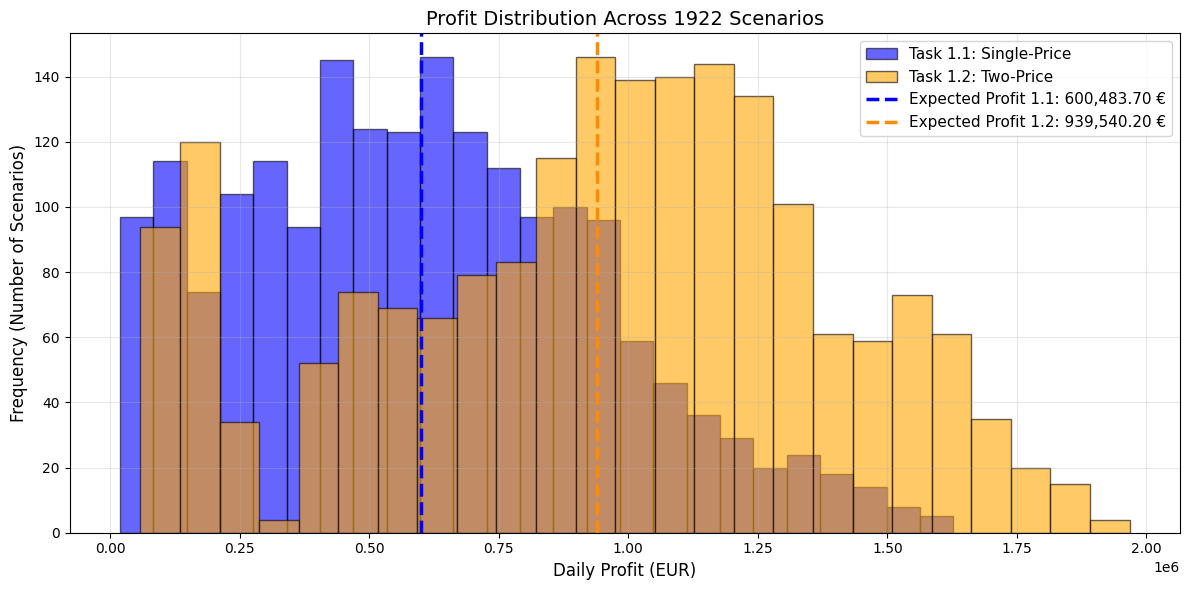

In [144]:
plt.figure(figsize=(12, 6))

# Plot histograms with transparency (alpha=0.6) so you can see where they overlap
plt.hist(scenario_profits, bins=25, alpha=0.6, label='Task 1.1: Single-Price', color='blue', edgecolor='black')
plt.hist(scenario_profits_2, bins=25, alpha=0.6, label='Task 1.2: Two-Price', color='orange', edgecolor='black')

# Add vertical lines for the Expected Profit (Mean)
mean_1 = np.mean(scenario_profits)
mean_2 = np.mean(scenario_profits_2)
plt.axvline(mean_1, color='blue', linestyle='dashed', linewidth=2.5, 
            label=f'Expected Profit 1.1: {mean_1:,.2f} €')
plt.axvline(mean_2, color='darkorange', linestyle='dashed', linewidth=2.5, 
            label=f'Expected Profit 1.2: {mean_2:,.2f} €')

plt.title('Profit Distribution Across 1922 Scenarios', fontsize=14)
plt.xlabel('Daily Profit (EUR)', fontsize=12)
plt.ylabel('Frequency (Number of Scenarios)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Task 1.3


--- Fold 1 / 8 ---
  In-sample  expected profit: 843,180.66 EUR
  Out-of-sample expected profit: 578,107.70 EUR

--- Fold 2 / 8 ---
  In-sample  expected profit: 812,406.80 EUR
  Out-of-sample expected profit: 582,503.96 EUR

--- Fold 3 / 8 ---
  In-sample  expected profit: 434,379.14 EUR
  Out-of-sample expected profit: 636,507.92 EUR

--- Fold 4 / 8 ---
  In-sample  expected profit: 358,654.73 EUR
  Out-of-sample expected profit: 647,325.69 EUR

--- Fold 5 / 8 ---
  In-sample  expected profit: 470,663.16 EUR
  Out-of-sample expected profit: 631,324.48 EUR

--- Fold 6 / 8 ---
  In-sample  expected profit: 566,915.29 EUR
  Out-of-sample expected profit: 617,574.18 EUR

--- Fold 7 / 8 ---
  In-sample  expected profit: 752,816.09 EUR
  Out-of-sample expected profit: 591,016.92 EUR

--- Fold 8 / 8 ---
  In-sample  expected profit: 650,918.68 EUR
  Out-of-sample expected profit: 605,573.70 EUR

Average in-sample  profit (8 folds): 611,241.82 EUR
Average out-of-sample profit (8 folds): 611

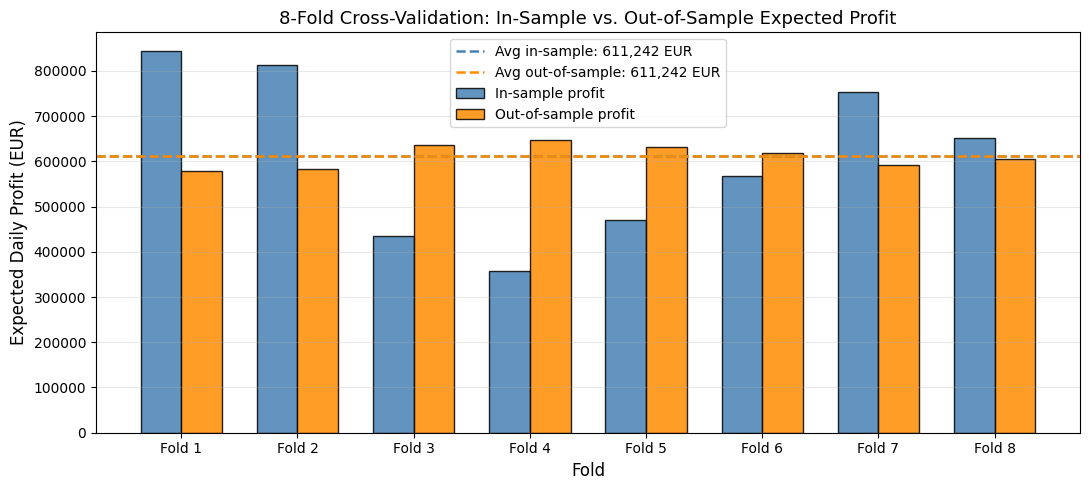

In [ ]:
# Setup: 1600 scenarios total (from our 1922, we use the first 1600)
# Split into 8 folds of 200 scenarios each.
# Each run: 1 fold (200) = in-sample, remaining 7 folds (1400) = out-of-sample.


# --- Use first 1600 scenarios to match assignment spec exactly ---
N_TOTAL = 1600
N_FOLDS = 8
FOLD_SIZE = N_TOTAL // N_FOLDS  # = 200 in-sample per run

# Slice all scenario arrays to first 1600
wind_cv    = wind_realized[:, :N_TOTAL]   # (24, 1600)
price_cv   = lambda_da[:, :N_TOTAL]       # (24, 1600)
si_cv      = SI_scenarios[:, :N_TOTAL]    # (24, 1600)
bp_cv      = si_cv * (1.25 * price_cv) + (1 - si_cv) * (0.85 * price_cv)

hours   = 24
P_nom   = 500

in_sample_profits  = []
out_sample_profits = []

for fold in range(N_FOLDS):
    print(f"\n--- Fold {fold + 1} / {N_FOLDS} ---")

    # --- Define in-sample and out-of-sample indices ---
    in_idx  = list(range(fold * FOLD_SIZE, (fold + 1) * FOLD_SIZE))   # 200 scenarios
    out_idx = list(set(range(N_TOTAL)) - set(in_idx))                  # 1400 scenarios

    n_in  = len(in_idx)   # 200
    n_out = len(out_idx)  # 1400

    # Slice data
    wind_in  = wind_cv[:, in_idx];   price_in  = price_cv[:, in_idx];   bp_in  = bp_cv[:, in_idx]
    wind_out = wind_cv[:, out_idx];  price_out = price_cv[:, out_idx];  bp_out = bp_cv[:, out_idx]

    prob_in = 1.0 / n_in

    # -------------------------------------------------------------------------
    # Step 1: Solve stochastic optimisation on IN-SAMPLE scenarios (one-price)
    # -------------------------------------------------------------------------
    m = gp.Model(f"CV_fold_{fold+1}")
    m.setParam('OutputFlag', 0)  # suppress solver output

    p_da      = m.addVars(hours, lb=0, ub=P_nom, name="p_da")
    delta_plus  = m.addVars(hours, n_in, lb=0, ub=P_nom, name="dp")
    delta_minus = m.addVars(hours, n_in, lb=0, ub=P_nom, name="dm")

    obj = gp.quicksum(
        prob_in * (
            price_in[t, s] * p_da[t]
            + bp_in[t, s]  * delta_plus[t, s]
            - bp_in[t, s]  * delta_minus[t, s]
        )
        for t in range(hours) for s in range(n_in)
    )
    m.setObjective(obj, GRB.MAXIMIZE)

    for t in range(hours):
        for s in range(n_in):
            m.addConstr(
                wind_in[t, s] - p_da[t] == delta_plus[t, s] - delta_minus[t, s]
            )
    m.optimize()

    # Extract optimal offers
    offers = np.array([p_da[t].X for t in range(hours)])

    # -------------------------------------------------------------------------
    # Step 2: Compute IN-SAMPLE expected profit (re-evaluate at optimal offers)
    # -------------------------------------------------------------------------
    in_profit = 0.0
    for s in range(n_in):
        for t in range(hours):
            d_pos = max(0.0, wind_in[t, s] - offers[t])
            d_neg = max(0.0, offers[t] - wind_in[t, s])
            in_profit += price_in[t, s] * offers[t] + bp_in[t, s] * d_pos - bp_in[t, s] * d_neg
    in_profit /= n_in
    in_sample_profits.append(in_profit)

    # -------------------------------------------------------------------------
    # Step 3: Compute OUT-OF-SAMPLE expected profit (fix offers, new scenarios)
    # -------------------------------------------------------------------------
    out_profit = 0.0
    for s in range(n_out):
        for t in range(hours):
            d_pos = max(0.0, wind_out[t, s] - offers[t])
            d_neg = max(0.0, offers[t] - wind_out[t, s])
            out_profit += price_out[t, s] * offers[t] + bp_out[t, s] * d_pos - bp_out[t, s] * d_neg
    out_profit /= n_out
    out_sample_profits.append(out_profit)

    print(f"  In-sample  expected profit: {in_profit:,.2f} EUR")
    print(f"  Out-of-sample expected profit: {out_profit:,.2f} EUR")

# =============================================================================
# Summary
# =============================================================================
avg_in  = np.mean(in_sample_profits)
avg_out = np.mean(out_sample_profits)

print(f"\n{'='*50}")
print(f"Average in-sample  profit (8 folds): {avg_in:,.2f} EUR")
print(f"Average out-of-sample profit (8 folds): {avg_out:,.2f} EUR")
print(f"Optimistic bias (in - out):           {avg_in - avg_out:,.2f} EUR")
print(f"{'='*50}")

# =============================================================================
# Plot
# =============================================================================
folds = np.arange(1, N_FOLDS + 1)
x = np.arange(N_FOLDS)
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, in_sample_profits,  width, label='In-sample profit',     color='steelblue',  edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, out_sample_profits, width, label='Out-of-sample profit', color='darkorange', edgecolor='black', alpha=0.85)

ax.axhline(avg_in,  color='steelblue',  linestyle='--', linewidth=1.8, label=f'Avg in-sample: {avg_in:,.0f} EUR')
ax.axhline(avg_out, color='darkorange', linestyle='--', linewidth=1.8, label=f'Avg out-of-sample: {avg_out:,.0f} EUR')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Expected Daily Profit (EUR)', fontsize=12)
ax.set_title('8-Fold Cross-Validation: In-Sample vs. Out-of-Sample Expected Profit', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in folds])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Task 1.4

Sweeping beta for One-Price scheme...
  β=0.00 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=0.10 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=0.20 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=0.30 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=0.50 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=0.75 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=1.00 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=1.50 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=2.00 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=3.00 | E[π]=600,484 EUR | CVaR=83,253 EUR
  β=5.00 | E[π]=600,484 EUR | CVaR=83,253 EUR

Sweeping beta for Two-Price scheme...
  β=0.00 | E[π]=939,540 EUR | CVaR=131,759 EUR
  β=0.10 | E[π]=939,540 EUR | CVaR=131,759 EUR
  β=0.20 | E[π]=939,540 EUR | CVaR=131,759 EUR
  β=0.30 | E[π]=939,540 EUR | CVaR=131,759 EUR
  β=0.50 | E[π]=939,540 EUR | CVaR=131,759 EUR
  β=0.75 | E[π]=939,540 EUR | CVaR=131,759 EUR
  β=1.00 | E[π]=939,540 EUR | CVaR=131,759 EUR
  β=1.50 | E[π]=939,540 EUR | CVaR=131,759 EUR
  β=2.00 | E[π]=939,540 EUR | CVaR=131,75

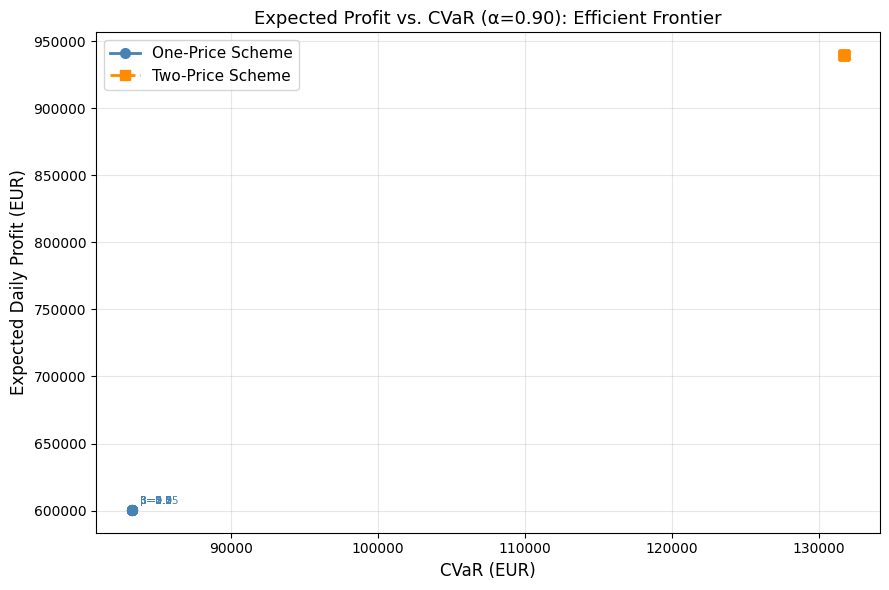

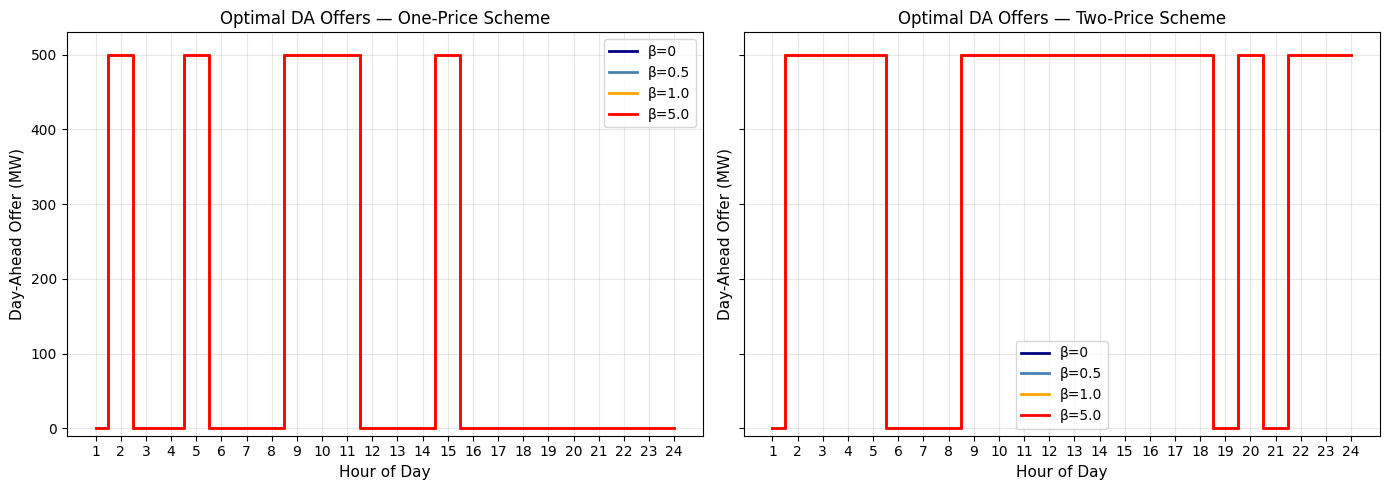

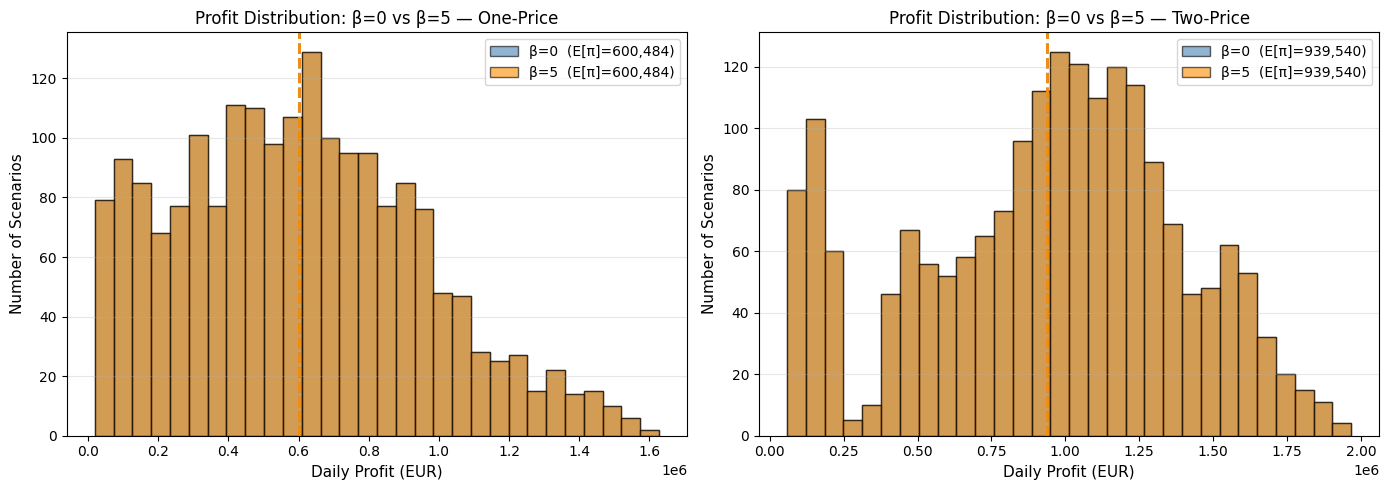

In [146]:
alpha = 0.90   # CVaR confidence level 
hours = 24
P_nom = 500
n_scenarios = wind_realized.shape[1]   # 1922
prob = 1.0 / n_scenarios

# Precompute balancing prices (same as Tasks 1.1 and 1.2)
lambda_bp = SI_scenarios * (1.25 * lambda_da) + (1 - SI_scenarios) * (0.85 * lambda_da)

# Beta values to sweep — start at 0 (risk-neutral), increase gradually
beta_values = [0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]

# Storage for results
results = {
    '1p': {'exp_profit': [], 'cvar': [], 'offers': []},
    '2p': {'exp_profit': [], 'cvar': [], 'offers': []},
}

def compute_cvar(profits, alpha):
    """Compute CVaR at confidence level alpha from a profit array."""
    sorted_profits = np.sort(profits)
    cutoff_idx = int(np.floor((1 - alpha) * len(sorted_profits)))
    cutoff_idx = max(cutoff_idx, 1)
    return np.mean(sorted_profits[:cutoff_idx])

def solve_risk_averse(scheme, beta):
    """
    Solve the risk-averse offering problem for a given scheme and beta.
    scheme: '1p' (one-price) or '2p' (two-price)
    beta:   non-negative weight on CVaR term
    Returns: (expected_profit, cvar, optimal_offers array)
    """
    m = gp.Model(f"RiskAverse_{scheme}_beta{beta:.2f}")
    m.setParam('OutputFlag', 0)

    # --- Decision variables ---
    p_da       = m.addVars(hours, lb=0, ub=P_nom, name="p_da")
    delta_plus  = m.addVars(hours, n_scenarios, lb=0, ub=P_nom, name="dp")
    delta_minus = m.addVars(hours, n_scenarios, lb=0, ub=P_nom, name="dm")
    zeta       = m.addVar(lb=-GRB.INFINITY, name="zeta")          # VaR variable
    eta        = m.addVars(n_scenarios, lb=0, name="eta")          # CVaR auxiliary

    # --- Per-scenario profit expression ---
    # Build profit_s[s] as a Gurobi LinExpr for each scenario
    if scheme == '1p':
        # One-price: all imbalances at BP
        profit_expr = {
            s: gp.quicksum(
                lambda_da[t, s] * p_da[t]
                + lambda_bp[t, s] * delta_plus[t, s]
                - lambda_bp[t, s] * delta_minus[t, s]
                for t in range(hours)
            )
            for s in range(n_scenarios)
        }
    else:
        # Two-price: beneficial rewarded, harmful penalised at BP
        profit_expr = {
            s: gp.quicksum(
                lambda_da[t, s] * p_da[t]
                + SI_scenarios[t, s] * (
                    1.25 * lambda_da[t, s] * delta_plus[t, s]
                    - 1.25 * lambda_da[t, s] * delta_minus[t, s]
                )
                + (1 - SI_scenarios[t, s]) * (
                    - 0.85 * lambda_da[t, s] * delta_plus[t, s]
                    + 0.85 * lambda_da[t, s] * delta_minus[t, s]
                )
                for t in range(hours)
            )
            for s in range(n_scenarios)
        }

    # --- Objective: Expected profit + beta * CVaR ---
    expected_profit_term = gp.quicksum(prob * profit_expr[s] for s in range(n_scenarios))
    cvar_term = zeta - (1.0 / (1.0 - alpha)) * gp.quicksum(prob * eta[s] for s in range(n_scenarios))
    m.setObjective(expected_profit_term + beta * cvar_term, GRB.MAXIMIZE)

    # --- Constraints ---
    # Imbalance balance constraint
    for t in range(hours):
        for s in range(n_scenarios):
            m.addConstr(
                wind_realized[t, s] - p_da[t] == delta_plus[t, s] - delta_minus[t, s]
            )

    # CVaR auxiliary constraints: eta_s >= zeta - profit_s
    for s in range(n_scenarios):
        m.addConstr(eta[s] >= zeta - profit_expr[s])

    m.optimize()

    if m.status != GRB.OPTIMAL:
        return None, None, None

    offers = np.array([p_da[t].X for t in range(hours)])

    # Compute realised profits post-optimisation
    scenario_profits = np.zeros(n_scenarios)
    for s in range(n_scenarios):
        for t in range(hours):
            dp = max(0.0, wind_realized[t, s] - offers[t])
            dm = max(0.0, offers[t] - wind_realized[t, s])
            if scheme == '1p':
                scenario_profits[s] += (
                    lambda_da[t, s] * offers[t]
                    + lambda_bp[t, s] * dp
                    - lambda_bp[t, s] * dm
                )
            else:
                si = SI_scenarios[t, s]
                scenario_profits[s] += (
                    lambda_da[t, s] * offers[t]
                    + si * (1.25 * lambda_da[t, s] * dp - 1.25 * lambda_da[t, s] * dm)
                    + (1 - si) * (-0.85 * lambda_da[t, s] * dp + 0.85 * lambda_da[t, s] * dm)
                )

    exp_profit = np.mean(scenario_profits)
    cvar_val   = compute_cvar(scenario_profits, alpha)

    return exp_profit, cvar_val, offers

# =============================================================================
# Run the sweep
# =============================================================================
print("Sweeping beta for One-Price scheme...")
for beta in beta_values:
    ep, cv, off = solve_risk_averse('1p', beta)
    results['1p']['exp_profit'].append(ep)
    results['1p']['cvar'].append(cv)
    results['1p']['offers'].append(off)
    print(f"  β={beta:.2f} | E[π]={ep:,.0f} EUR | CVaR={cv:,.0f} EUR")

print("\nSweeping beta for Two-Price scheme...")
for beta in beta_values:
    ep, cv, off = solve_risk_averse('2p', beta)
    results['2p']['exp_profit'].append(ep)
    results['2p']['cvar'].append(cv)
    results['2p']['offers'].append(off)
    print(f"  β={beta:.2f} | E[π]={ep:,.0f} EUR | CVaR={cv:,.0f} EUR")

# =============================================================================
# Plot 1: Expected Profit vs CVaR (Efficient Frontier)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(results['1p']['cvar'], results['1p']['exp_profit'],
        'o-', color='steelblue', lw=2, markersize=7, label='One-Price Scheme')
ax.plot(results['2p']['cvar'], results['2p']['exp_profit'],
        's--', color='darkorange', lw=2, markersize=7, label='Two-Price Scheme')

# Annotate beta values on one-price curve
for i, beta in enumerate(beta_values):
    ax.annotate(f'β={beta}',
                xy=(results['1p']['cvar'][i], results['1p']['exp_profit'][i]),
                xytext=(6, 4), textcoords='offset points', fontsize=7.5, color='steelblue')

ax.set_xlabel('CVaR (EUR)', fontsize=12)
ax.set_ylabel('Expected Daily Profit (EUR)', fontsize=12)
ax.set_title('Expected Profit vs. CVaR (α=0.90): Efficient Frontier', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('efficient_frontier.png', dpi=150)
plt.show()

# =============================================================================
# Plot 2: Offering strategy at selected beta values (one-price)
# =============================================================================
selected_betas = [0, 0.5, 1.0, 5.0]
selected_idx   = [beta_values.index(b) for b in selected_betas]
hours_arr = np.arange(1, 25)
colors = ['navy', 'steelblue', 'orange', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for scheme, ax, label in zip(['1p', '2p'], axes, ['One-Price', 'Two-Price']):
    for idx, beta, color in zip(selected_idx, selected_betas, colors):
        off = results[scheme]['offers'][idx]
        ax.step(hours_arr, off, where='mid', lw=2, color=color, label=f'β={beta}')
    ax.set_title(f'Optimal DA Offers — {label} Scheme', fontsize=12)
    ax.set_xlabel('Hour of Day', fontsize=11)
    ax.set_ylabel('Day-Ahead Offer (MW)', fontsize=11)
    ax.set_ylim(-10, 530)
    ax.set_xticks(hours_arr)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('offers_by_beta.png', dpi=150)
plt.show()

# =============================================================================
# Plot 3: Profit distribution at beta=0 vs beta=5 (one-price only)
# =============================================================================
def get_profits(scheme, beta_idx):
    offers = results[scheme]['offers'][beta_idx]
    profits = np.zeros(n_scenarios)
    for s in range(n_scenarios):
        for t in range(hours):
            dp = max(0.0, wind_realized[t, s] - offers[t])
            dm = max(0.0, offers[t] - wind_realized[t, s])
            if scheme == '1p':
                profits[s] += (lambda_da[t,s]*offers[t]
                               + lambda_bp[t,s]*dp - lambda_bp[t,s]*dm)
            else:
                si = SI_scenarios[t,s]
                profits[s] += (lambda_da[t,s]*offers[t]
                               + si*(1.25*lambda_da[t,s]*dp - 1.25*lambda_da[t,s]*dm)
                               + (1-si)*(-0.85*lambda_da[t,s]*dp + 0.85*lambda_da[t,s]*dm))
    return profits

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for scheme, ax, label in zip(['1p', '2p'], axes, ['One-Price', 'Two-Price']):
    p0 = get_profits(scheme, 0)    # beta=0
    p5 = get_profits(scheme, -1)   # beta=5
    bins = 30
    ax.hist(p0, bins=bins, alpha=0.6, color='steelblue', edgecolor='black',
            label=f'β=0  (E[π]={np.mean(p0):,.0f})')
    ax.hist(p5, bins=bins, alpha=0.6, color='darkorange', edgecolor='black',
            label=f'β=5  (E[π]={np.mean(p5):,.0f})')
    ax.axvline(np.mean(p0), color='steelblue', linestyle='--', lw=2)
    ax.axvline(np.mean(p5), color='darkorange', linestyle='--', lw=2)
    ax.set_title(f'Profit Distribution: β=0 vs β=5 — {label}', fontsize=12)
    ax.set_xlabel('Daily Profit (EUR)', fontsize=11)
    ax.set_ylabel('Number of Scenarios', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('dist_beta_comparison.png', dpi=150)
plt.show()